# 12 - Visualizaciones para el TFM

Este notebook genera las figuras y tablas agregadas recomendadas para la memoria del TFM.

**Pensado para GitHub y trabajo en equipo:**

- No usa rutas absolutas de ninguna persona.
- Busca automaticamente la raiz del repositorio.
- Lee solo los CSV finales versionados en `data/raw/`.
- Exporta resultados agregados a `docs/overleaf/figures/` y `docs/overleaf/tables/`.
- No exporta texto original de tweets, usernames ni identificadores personales.

Para ejecutarlo en local desde una copia del repositorio:

```bash
pip install -r requirements.txt
jupyter notebook
```


## 0. Configuracion reproducible

**Uso en el TFM:** no se incluye como visualizacion. Esta celda prepara rutas, estilo y funciones auxiliares.

Las figuras se guardan en PNG y PDF para que podais usar PNG en borradores y PDF en Overleaf si quereis maxima calidad.

In [15]:
from pathlib import Path
import warnings

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter, MaxNLocator
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Falta la libreria '{exc.name}'. Instala las dependencias desde la raiz del repositorio con: "
        "pip install -r requirements.txt"
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

def find_repo_root(start=None):
    """Encuentra la raiz del repo subiendo desde el directorio actual."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        has_data = (candidate / "data" / "raw").exists()
        has_overleaf = (candidate / "docs" / "overleaf").exists()
        if has_data and has_overleaf:
            return candidate
    raise FileNotFoundError(
        "No encuentro la raiz del repositorio. Ejecuta este notebook desde el repo o desde la carpeta notebooks/."
    )

REPO_ROOT = find_repo_root()
DATA_RAW = REPO_ROOT / "data" / "raw"
OVERLEAF = REPO_ROOT / "docs" / "overleaf"
FIG_DIR = OVERLEAF / "figures"
TABLE_DIR = OVERLEAF / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

US_CSV = DATA_RAW / "scam_us_FINAL_classified.csv"
ES_CSV = DATA_RAW / "scam_es_FINAL_classified_corregido.csv"

for path in [US_CSV, ES_CSV]:
    if not path.exists():
        raise FileNotFoundError(f"No encuentro {path.relative_to(REPO_ROOT)}")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
    "legend.frameon": False,
})

COUNTRY_COLORS = {
    "Estados Unidos": "#2F6B8F",
    "Espana": "#C75646",
}

CATEGORY_LABELS = {
    "phishing_identity": "Phishing / robo de identidad",
    "investment_crypto": "Inversion / cripto",
    "ponzi_pyramid": "Ponzi / piramidal",
    "employment": "Empleo",
    "romance": "Romance",
    "bank_wire": "Banco / transferencias",
    "gov_impersonation": "Suplantacion publica",
    "tax": "Fiscal",
    "tech_support": "Soporte tecnico",
    "payment_app": "Apps de pago",
    "charity": "Caridad / donaciones",
    "corporate": "Corporativo / bursatil",
    "insurance": "Seguros",
    "not_related": "No relacionado",
}

QUERY_LABELS = {
    "crypto": "Cripto",
    "phishing": "Phishing",
    "impersonation": "Suplantacion",
    "payment_apps": "Apps de pago",
    "romance_monetary": "Romance",
    "romance": "Romance",
}

TOPIC_STOPWORDS = {
    "a", "an", "and", "are", "as", "be", "by", "for", "from", "in", "is", "it", "of", "on", "or",
    "that", "the", "this", "to", "will", "with", "your", "you", "de", "del", "la", "el", "en", "que",
    "por", "una", "un", "los", "las", "para", "con", "se", "su", "sus"
}

def pct_formatter(x, pos):
    return f"{x:.0f}%"

def label_category(code):
    return CATEGORY_LABELS.get(code, code)

def save_figure(fig, name):
    """Guarda una figura en PNG y PDF dentro de docs/overleaf/figures."""
    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Guardado: {png_path.relative_to(REPO_ROOT)}")
    print(f"Guardado: {pdf_path.relative_to(REPO_ROOT)}")
    return png_path, pdf_path

def export_table(df, name, caption=None, label=None):
    """Exporta una tabla agregada a CSV y, si pandas lo permite, a LaTeX."""
    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"Guardado: {csv_path.relative_to(REPO_ROOT)}")
    try:
        df.to_latex(tex_path, index=False, escape=True, caption=caption, label=label)
        print(f"Guardado: {tex_path.relative_to(REPO_ROOT)}")
    except Exception as exc:
        print(f"No se pudo exportar LaTeX para {name}: {exc}")
    return csv_path

print(f"Raiz del repo: {REPO_ROOT}")
print(f"Figuras: {FIG_DIR.relative_to(REPO_ROOT)}")
print(f"Tablas: {TABLE_DIR.relative_to(REPO_ROOT)}")


Raiz del repo: /Users/alicia/Desktop/UNAV/materias/TFM/github
Figuras: docs/overleaf/figures
Tablas: docs/overleaf/tables


## 1. Carga de datos finales

**Uso en el TFM:** no es una visualizacion. Esta celda carga los corpus finales que sostienen todas las figuras.

Entradas esperadas:

- `data/raw/scam_us_FINAL_classified.csv`
- `data/raw/scam_es_FINAL_classified_corregido.csv`

In [16]:
us = pd.read_csv(US_CSV)
es = pd.read_csv(ES_CSV)

for df, country in [(us, "Estados Unidos"), (es, "Espana")]:
    df["country"] = country
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
    df["month"] = df["created_at"].dt.to_period("M").astype(str)
    df["confidence_score"] = pd.to_numeric(df["confidence_score"], errors="coerce")
    for col in ["retweet_count", "reply_count", "like_count", "quote_count", "n_words", "n_hashtags", "n_mentions", "n_urls", "user_followers"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

combined = pd.concat([us, es], ignore_index=True)

print(f"EEUU:   {len(us):,} tweets")
print(f"Espana: {len(es):,} tweets")
display(combined[["country", "created_at", "predicted_category", "confidence_score", "is_relevant"]].head())


EEUU:   1,928 tweets
Espana: 1,229 tweets


/var/folders/4s/np3_lc3x5ds9nrg_gm6wz78w0000gn/T/ipykernel_27676/49644166.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)
/var/folders/4s/np3_lc3x5ds9nrg_gm6wz78w0000gn/T/ipykernel_27676/49644166.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)


,country,created_at,predicted_category,confidence_score,is_relevant
0,Estados Unidos,2025-12-31 23:47:29+00:00,ponzi_pyramid,0.500952,True
1,Estados Unidos,2025-12-31 23:31:25+00:00,phishing_identity,0.209942,True
2,Estados Unidos,2025-12-31 23:00:29+00:00,ponzi_pyramid,0.540315,True
3,Estados Unidos,2025-12-31 22:39:57+00:00,romance,0.322643,True
4,Estados Unidos,2025-12-31 22:26:03+00:00,tax,0.611685,True


## 2. Tabla descriptiva de los corpus finales

**Donde ponerla:** `Materiales y Metodos`, despues de la seccion `Estructura de los Datos` o al inicio de `Resultados`.

**Titulo sugerido:** `Caracteristicas descriptivas de los corpus finales`.

**Leyenda sugerida:** `Resumen agregado de los corpus estadounidense y espanol utilizados para el analisis NLP. Las metricas de interaccion se presentan como medianas para reducir el efecto de valores extremos.`

In [17]:
def corpus_summary(df, country):
    relevant = df["is_relevant"].astype(str).str.lower().eq("true") if "is_relevant" in df.columns else pd.Series([np.nan] * len(df))
    return {
        "Corpus": country,
        "Tweets": len(df),
        "Periodo": f"{df['created_at'].min().date()} - {df['created_at'].max().date()}",
        "Relevantes (%)": round(relevant.mean() * 100, 1),
        "Palabras medias": round(df["n_words"].mean(), 1),
        "URLs medias": round(df["n_urls"].mean(), 2),
        "Hashtags medios": round(df["n_hashtags"].mean(), 2),
        "Likes mediana": round(df["like_count"].median(), 1),
        "Retweets mediana": round(df["retweet_count"].median(), 1),
        "Confianza media": round(df["confidence_score"].mean(), 3),
    }

tabla_corpus = pd.DataFrame([
    corpus_summary(us, "Estados Unidos"),
    corpus_summary(es, "Espana"),
])

export_table(
    tabla_corpus,
    "tabla_caracteristicas_corpus",
    caption="Caracteristicas descriptivas de los corpus finales.",
    label="tab:caracteristicas_corpus",
)

display(tabla_corpus)


Guardado: docs/overleaf/tables/tabla_caracteristicas_corpus.csv
Guardado: docs/overleaf/tables/tabla_caracteristicas_corpus.tex


,Corpus,Tweets,Periodo,Relevantes (%),Palabras medias,URLs medias,Hashtags medios,Likes mediana,Retweets mediana,Confianza media
0,Estados Unidos,1928,2025-01-02 - 2025-12-31,98.1,28.3,0.97,0.55,0.0,0.0,0.596
1,Espana,1229,2025-01-17 - 2025-12-31,99.8,25.9,1.17,0.97,0.0,0.0,0.515


## 3. Figura: flujo de construccion del corpus

**Donde ponerla:** `Materiales y Metodos`, al final de `Ingesta de datos: fuente y consultas` o antes de `Preprocesamiento y limpieza`.

**Titulo sugerido:** `Flujo de construccion del corpus de analisis`.

**Leyenda sugerida:** `Etapas principales de extraccion, deduplicacion, filtrado estructural, limpieza anti-bot y clasificacion NLP. En el corpus espanol se muestra el corpus final versionado, ya que los CSV intermedios no forman parte del repositorio.`

Guardado: docs/overleaf/figures/fig_01_flujo_construccion_corpus.png
Guardado: docs/overleaf/figures/fig_01_flujo_construccion_corpus.pdf


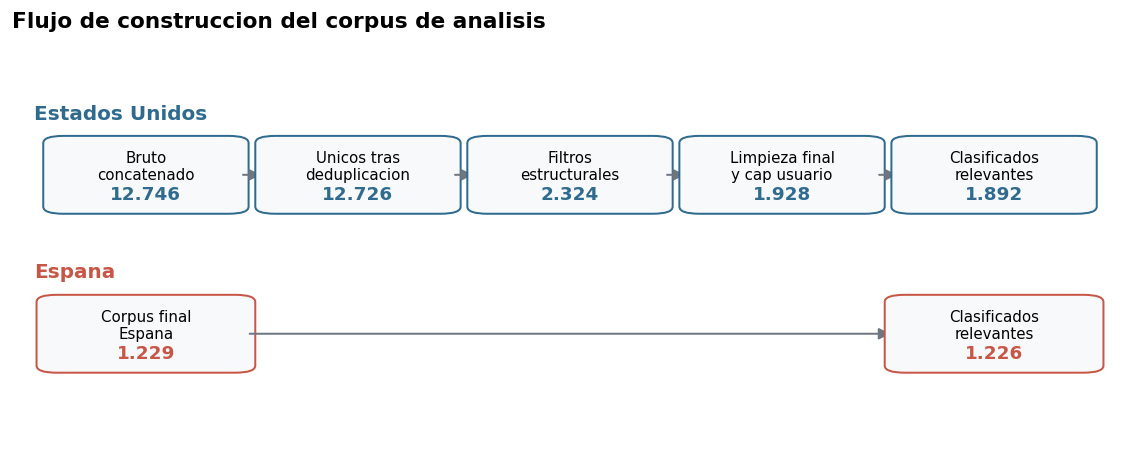

In [18]:
pipeline_us = [
    ("Bruto\nconcatenado", 12746),
    ("Unicos tras\ndeduplicacion", 12726),
    ("Filtros\nestructurales", 2324),
    ("Limpieza final\ny cap usuario", len(us)),
    ("Clasificados\nrelevantes", int(us["is_relevant"].astype(str).str.lower().eq("true").sum())),
]

pipeline_es = [
    ("Corpus final\nEspana", len(es)),
    ("Clasificados\nrelevantes", int(es["is_relevant"].astype(str).str.lower().eq("true").sum())),
]

def draw_pipeline(ax, steps, y, color, label):
    ax.text(0.02, y + 0.14, label, fontsize=12, fontweight="bold", color=color, transform=ax.transAxes)
    x_positions = np.linspace(0.12, 0.88, len(steps))
    box_w = min(0.16, 0.74 / max(len(steps), 1))
    box_h = 0.16
    for i, ((name, value), x) in enumerate(zip(steps, x_positions)):
        patch = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.018,rounding_size=0.018",
            linewidth=1.2, edgecolor=color, facecolor="#F7F9FB", transform=ax.transAxes,
        )
        ax.add_patch(patch)
        ax.text(x, y + 0.02, name, ha="center", va="center", fontsize=9, transform=ax.transAxes)
        ax.text(x, y - 0.05, f"{value:,}".replace(",", "."), ha="center", va="center", fontsize=11, fontweight="bold", color=color, transform=ax.transAxes)
        if i < len(steps) - 1:
            arrow = FancyArrowPatch(
                (x + box_w / 2 + 0.01, y), (x_positions[i + 1] - box_w / 2 - 0.01, y),
                arrowstyle="-|>", mutation_scale=14, linewidth=1.2, color="#6E7781", transform=ax.transAxes,
            )
            ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(12, 4.3))
ax.set_axis_off()
draw_pipeline(ax, pipeline_us, y=0.68, color=COUNTRY_COLORS["Estados Unidos"], label="Estados Unidos")
draw_pipeline(ax, pipeline_es, y=0.28, color=COUNTRY_COLORS["Espana"], label="Espana")
ax.set_title("Flujo de construccion del corpus de analisis", loc="left", pad=12, fontweight="bold")
save_figure(fig, "fig_01_flujo_construccion_corpus")
plt.show()


## 4. Figura y tabla: distribucion comparada de categorias

**Donde ponerla:** `Resultados`, primera visualizacion principal del capitulo.

**Titulo sugerido:** `Distribucion comparada de tipologias de fraude en EE. UU. y Espana`.

**Leyenda sugerida:** `Porcentaje de tweets asignados a cada categoria por el clasificador zero-shot BART-MNLI. En Espana se emplea la categoria corregida tras la regla de post-correccion.`

Guardado: docs/overleaf/tables/tabla_distribucion_categorias.csv
Guardado: docs/overleaf/tables/tabla_distribucion_categorias.tex
Guardado: docs/overleaf/figures/fig_02_distribucion_categorias_comparada.png
Guardado: docs/overleaf/figures/fig_02_distribucion_categorias_comparada.pdf


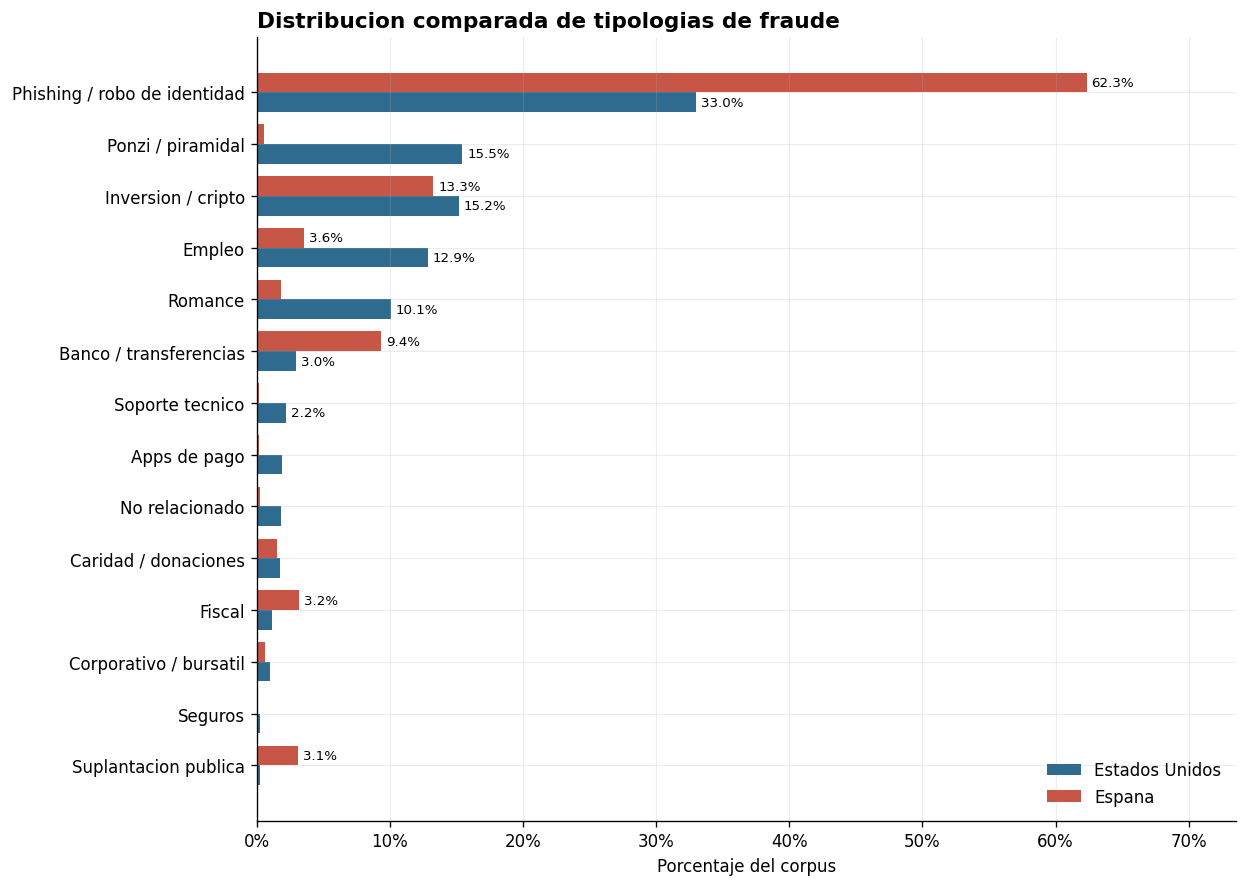

,Categoria,EEUU n,EEUU %,Espana n,Espana %,Diferencia Espana-EEUU (p.p.)
0,Phishing / robo de identidad,636,33.0,766.0,62.3,29.3
1,Ponzi / piramidal,298,15.5,7.0,0.6,-14.9
2,Inversion / cripto,293,15.2,163.0,13.3,-1.9
3,Empleo,248,12.9,44.0,3.6,-9.3
4,Romance,194,10.1,23.0,1.9,-8.2
5,Banco / transferencias,57,3.0,115.0,9.4,6.4
6,Soporte tecnico,43,2.2,2.0,0.2,-2.1
7,Apps de pago,37,1.9,2.0,0.2,-1.8
8,No relacionado,36,1.9,3.0,0.2,-1.6
9,Caridad / donaciones,34,1.8,19.0,1.5,-0.2


In [19]:
def category_distribution(df, prefix):
    counts = df["predicted_category"].value_counts()
    out = counts.rename(f"{prefix}_n").to_frame()
    out[f"{prefix}_pct"] = out[f"{prefix}_n"] / len(df) * 100
    return out

comp = category_distribution(us, "us").join(category_distribution(es, "es"), how="outer").fillna(0)
comp = comp.reset_index(names="category")
comp["category_label"] = comp["category"].map(label_category)
comp["delta_es_us_pp"] = comp["es_pct"] - comp["us_pct"]
comp = comp.sort_values(["us_pct", "es_pct"], ascending=False).reset_index(drop=True)

tabla_categorias = comp[["category_label", "us_n", "us_pct", "es_n", "es_pct", "delta_es_us_pp"]].copy()
tabla_categorias.columns = ["Categoria", "EEUU n", "EEUU %", "Espana n", "Espana %", "Diferencia Espana-EEUU (p.p.)"]
for col in ["EEUU %", "Espana %", "Diferencia Espana-EEUU (p.p.)"]:
    tabla_categorias[col] = tabla_categorias[col].round(1)

export_table(
    tabla_categorias,
    "tabla_distribucion_categorias",
    caption="Frecuencia absoluta y relativa por categoria predicha.",
    label="tab:distribucion_categorias",
)

plot_df = comp.sort_values("us_pct", ascending=True)
y = np.arange(len(plot_df))
height = 0.38

fig, ax = plt.subplots(figsize=(10.5, 7.5))
bars_us = ax.barh(y - height / 2, plot_df["us_pct"], height, label="Estados Unidos", color=COUNTRY_COLORS["Estados Unidos"])
bars_es = ax.barh(y + height / 2, plot_df["es_pct"], height, label="Espana", color=COUNTRY_COLORS["Espana"])
ax.set_yticks(y)
ax.set_yticklabels(plot_df["category_label"])
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.set_xlabel("Porcentaje del corpus")
ax.set_title("Distribucion comparada de tipologias de fraude", loc="left", fontweight="bold")
ax.legend(loc="lower right")
ax.set_xlim(0, max(plot_df["us_pct"].max(), plot_df["es_pct"].max()) * 1.18)
ax.bar_label(bars_us, labels=[f"{v:.1f}%" if v >= 2 else "" for v in plot_df["us_pct"]], padding=3, fontsize=8)
ax.bar_label(bars_es, labels=[f"{v:.1f}%" if v >= 2 else "" for v in plot_df["es_pct"]], padding=3, fontsize=8)
fig.tight_layout()
save_figure(fig, "fig_02_distribucion_categorias_comparada")
plt.show()

display(tabla_categorias)


## 5. Figura: evolucion mensual de las categorias principales

**Donde ponerla:** `Resultados`, despues de la distribucion general de categorias.

**Titulo sugerido:** `Evolucion temporal de las principales tipologias de fraude durante 2025`.

**Leyenda sugerida:** `Frecuencia mensual de las cinco categorias mas representadas en cada corpus. Cada panel usa las categorias principales de su propio contexto nacional.`

Guardado: docs/overleaf/figures/fig_03_evolucion_mensual_categorias.png
Guardado: docs/overleaf/figures/fig_03_evolucion_mensual_categorias.pdf


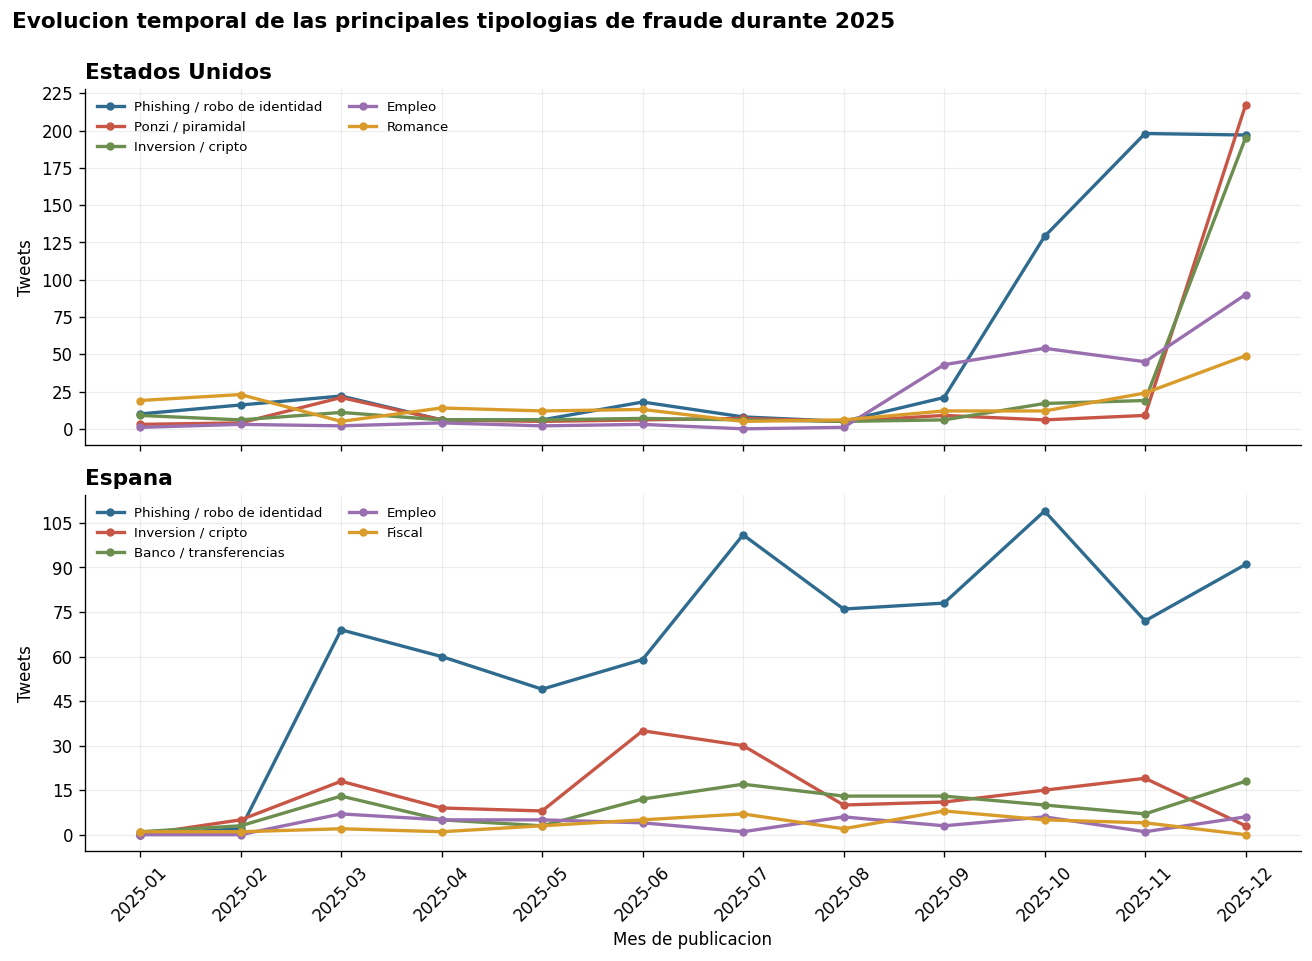

In [20]:
CATEGORY_COLORS = [
    "#2F6B8F", "#C75646", "#6C8E4E", "#9A6FB0", "#D99C2B", "#4C7C7D", "#8C564B", "#7F7F7F"
]

def monthly_top_categories(df, top_n=5):
    top = df["predicted_category"].value_counts().head(top_n).index.tolist()
    months = pd.period_range("2025-01", "2025-12", freq="M").astype(str)
    monthly = (
        df[df["predicted_category"].isin(top)]
        .groupby(["month", "predicted_category"])
        .size()
        .unstack(fill_value=0)
        .reindex(months, fill_value=0)
    )
    return monthly[top]

monthly_us = monthly_top_categories(us)
monthly_es = monthly_top_categories(es)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, monthly, title in [
    (axes[0], monthly_us, "Estados Unidos"),
    (axes[1], monthly_es, "Espana"),
]:
    for i, category in enumerate(monthly.columns):
        ax.plot(monthly.index, monthly[category], marker="o", linewidth=2, markersize=4, label=label_category(category), color=CATEGORY_COLORS[i])
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel("Tweets")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(ncol=2, fontsize=8, loc="upper left")

axes[-1].set_xlabel("Mes de publicacion")
axes[-1].tick_params(axis="x", rotation=45)
fig.suptitle("Evolucion temporal de las principales tipologias de fraude durante 2025", x=0.01, y=0.995, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
save_figure(fig, "fig_03_evolucion_mensual_categorias")
plt.show()


## 6. Figura y tabla: confianza del clasificador

**Donde ponerla:** `Resultados` o subseccion de validacion metodologica.

**Titulo sugerido:** `Distribucion de la confianza del clasificador zero-shot por categoria`.

**Leyenda sugerida:** `Puntuacion de confianza asignada por BART-MNLI a la categoria predicha. Se muestran categorias con al menos 20 observaciones en alguno de los dos corpus para evitar boxplots inestables.`

Guardado: docs/overleaf/tables/tabla_confianza_clasificador.csv
Guardado: docs/overleaf/tables/tabla_confianza_clasificador.tex
Guardado: docs/overleaf/figures/fig_04_confianza_clasificador_por_categoria.png
Guardado: docs/overleaf/figures/fig_04_confianza_clasificador_por_categoria.pdf


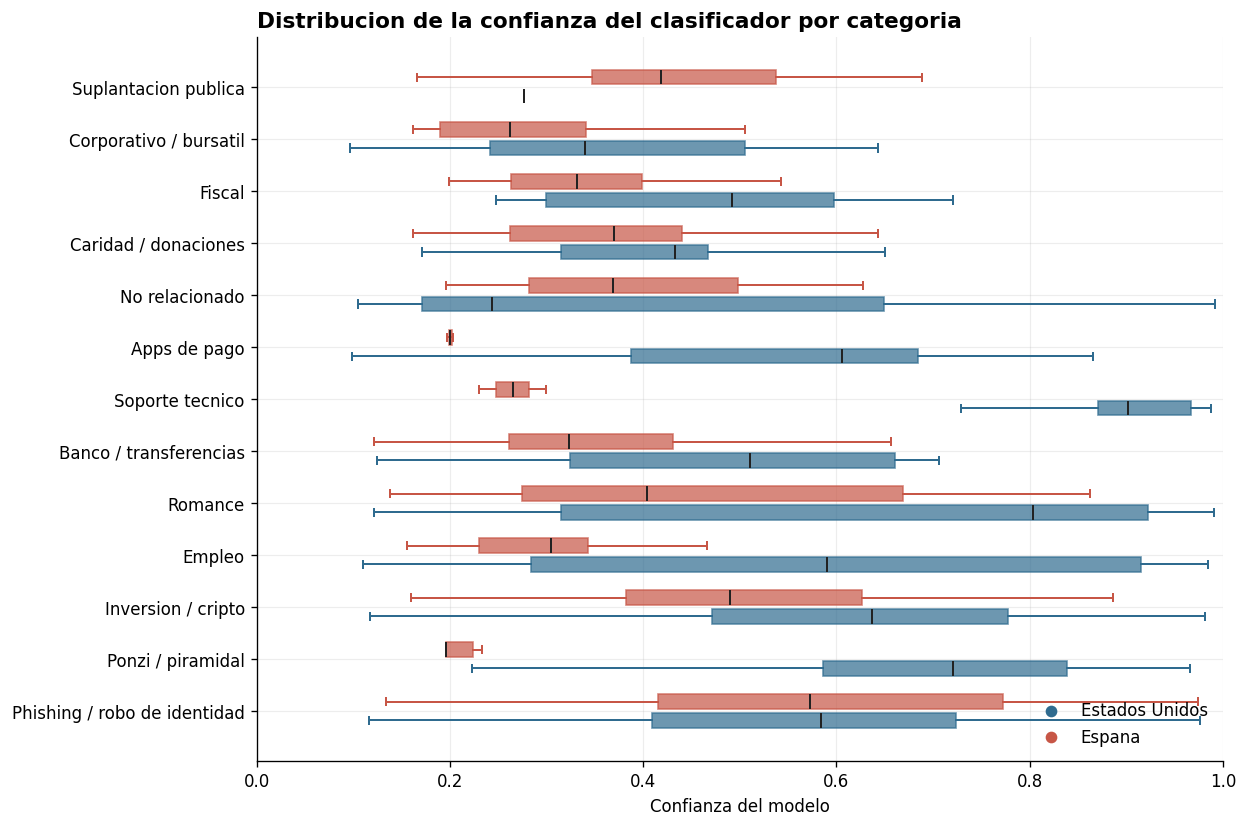

,country,Categoria,n,confianza_media,confianza_mediana,confianza_min,confianza_max
0,Espana,Banco / transferencias,115,0.350,0.323,0.121,0.821
1,Espana,Caridad / donaciones,19,0.367,0.370,0.162,0.644
2,Espana,Corporativo / bursatil,8,0.289,0.263,0.162,0.506
3,Espana,Empleo,44,0.303,0.305,0.156,0.626
4,Espana,Suplantacion publica,38,0.442,0.419,0.166,0.893
5,Espana,Inversion / cripto,163,0.489,0.490,0.160,0.887
6,Espana,No relacionado,3,0.397,0.369,0.196,0.628
7,Espana,Apps de pago,2,0.200,0.200,0.198,0.203
8,Espana,Phishing / robo de identidad,766,0.583,0.573,0.134,0.974
9,Espana,Ponzi / piramidal,7,0.231,0.196,0.196,0.387


In [21]:
MIN_N_BOXPLOT = 20
counts_by_country = combined.groupby(["country", "predicted_category"]).size().unstack(fill_value=0)
eligible_categories = []
for cat in comp["category"]:
    us_n = counts_by_country.loc["Estados Unidos", cat] if cat in counts_by_country.columns else 0
    es_n = counts_by_country.loc["Espana", cat] if cat in counts_by_country.columns else 0
    if max(us_n, es_n) >= MIN_N_BOXPLOT and min(us_n, es_n) > 0:
        eligible_categories.append(cat)

conf_table = (
    combined[combined["predicted_category"].isin(eligible_categories)]
    .groupby(["country", "predicted_category"])
    .agg(
        n=("confidence_score", "count"),
        confianza_media=("confidence_score", "mean"),
        confianza_mediana=("confidence_score", "median"),
        confianza_min=("confidence_score", "min"),
        confianza_max=("confidence_score", "max"),
    )
    .reset_index()
)
conf_table["Categoria"] = conf_table["predicted_category"].map(label_category)
conf_table = conf_table[["country", "Categoria", "n", "confianza_media", "confianza_mediana", "confianza_min", "confianza_max"]]
for col in ["confianza_media", "confianza_mediana", "confianza_min", "confianza_max"]:
    conf_table[col] = conf_table[col].round(3)

export_table(
    conf_table,
    "tabla_confianza_clasificador",
    caption="Confianza del clasificador zero-shot por categoria y corpus.",
    label="tab:confianza_clasificador",
)

positions = np.arange(len(eligible_categories))
offset = 0.18
fig, ax = plt.subplots(figsize=(10.5, 7))

for country, color, delta in [
    ("Estados Unidos", COUNTRY_COLORS["Estados Unidos"], -offset),
    ("Espana", COUNTRY_COLORS["Espana"], offset),
]:
    data = [
        combined.loc[(combined["country"] == country) & (combined["predicted_category"] == cat), "confidence_score"].dropna().values
        for cat in eligible_categories
    ]
    bp = ax.boxplot(
        data,
        positions=positions + delta,
        vert=False,
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.70)
        patch.set_edgecolor(color)
    for key in ["whiskers", "caps", "medians"]:
        for line in bp[key]:
            line.set_color(color if key != "medians" else "#222222")
            line.set_linewidth(1.2)
    ax.scatter([], [], color=color, label=country)

ax.set_yticks(positions)
ax.set_yticklabels([label_category(cat) for cat in eligible_categories])
ax.set_xlabel("Confianza del modelo")
ax.set_xlim(0, 1)
ax.set_title("Distribucion de la confianza del clasificador por categoria", loc="left", fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "fig_04_confianza_clasificador_por_categoria")
plt.show()

display(conf_table)


## 7. Figura: heatmap query de extraccion vs categoria predicha

**Donde ponerla:** `Resultados` o `Anexo` si el capitulo queda demasiado cargado.

**Titulo sugerido:** `Relacion entre terminos de busqueda y categorias predichas`.

**Leyenda sugerida:** `Cada celda representa el numero de tweets extraidos por una familia de query y asignados a una categoria final. La escala de color usa log(1+n) para hacer visibles categorias minoritarias.`

Guardado: docs/overleaf/figures/fig_05_heatmap_query_categoria.png
Guardado: docs/overleaf/figures/fig_05_heatmap_query_categoria.pdf


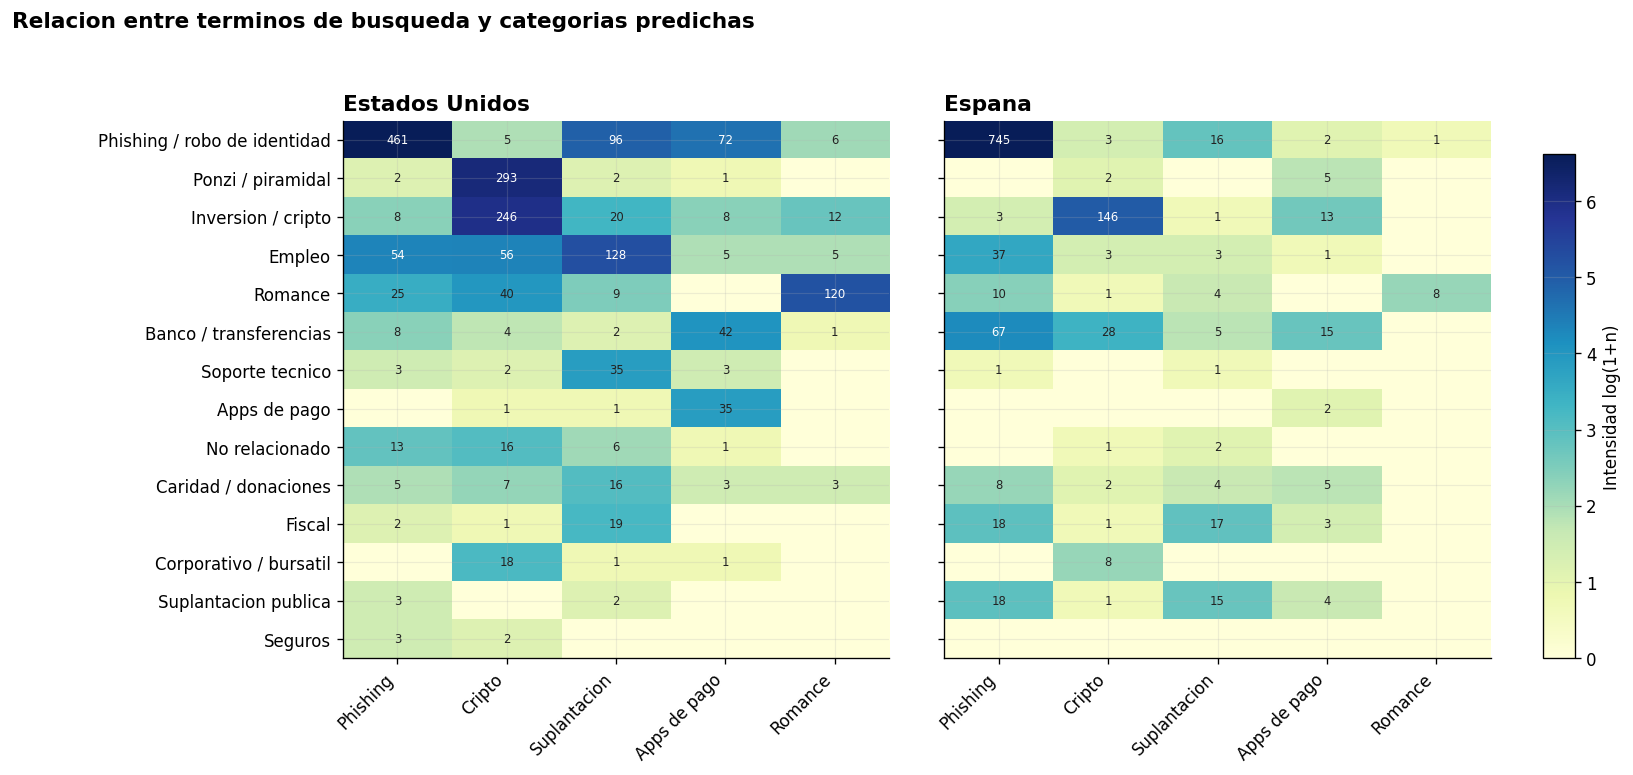

In [22]:
def query_category_matrix(df):
    records = []
    for _, row in df.iterrows():
        labels = str(row.get("query_labels", "")).split(",")
        for label in labels:
            label = label.strip()
            if label:
                records.append({"query": QUERY_LABELS.get(label, label), "category": row["predicted_category"]})
    long = pd.DataFrame(records)
    matrix = pd.crosstab(long["category"], long["query"])
    category_order = [cat for cat in comp["category"] if cat in matrix.index]
    query_order = matrix.sum(axis=0).sort_values(ascending=False).index.tolist()
    return matrix.reindex(index=category_order, columns=query_order, fill_value=0)

matrix_us = query_category_matrix(us)
matrix_es = query_category_matrix(es)
common_category_order = comp["category"].tolist()
common_query_order = sorted(
    set(matrix_us.columns) | set(matrix_es.columns),
    key=lambda q: -((matrix_us[q].sum() if q in matrix_us.columns else 0) + (matrix_es[q].sum() if q in matrix_es.columns else 0)),
)
matrix_us = matrix_us.reindex(index=common_category_order, columns=common_query_order, fill_value=0)
matrix_es = matrix_es.reindex(index=common_category_order, columns=common_query_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 7), sharey=True)
for ax, matrix, title in [(axes[0], matrix_us, "Estados Unidos"), (axes[1], matrix_es, "Espana")]:
    values = np.log1p(matrix.values)
    im = ax.imshow(values, aspect="auto", cmap="YlGnBu")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_yticklabels([label_category(cat) for cat in matrix.index])
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = int(matrix.iloc[i, j])
            if value > 0:
                color = "white" if values[i, j] > values.max() * 0.62 else "#222222"
                ax.text(j, i, str(value), ha="center", va="center", fontsize=7, color=color)

# Barra de color fuera de los paneles: evita que caiga sobre el segundo heatmap.
fig.subplots_adjust(left=0.20, right=0.86, top=0.86, bottom=0.22, wspace=0.10)
cbar_ax = fig.add_axes([0.89, 0.22, 0.018, 0.60])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Intensidad log(1+n)")
fig.suptitle("Relacion entre terminos de busqueda y categorias predichas", x=0.01, y=0.99, ha="left", fontweight="bold", fontsize=13)
save_figure(fig, "fig_05_heatmap_query_categoria")
plt.show()


## 8. Figura: post-correccion espanola de la estafa del hijo en apuros

**Donde ponerla:** `Materiales y Metodos` si se explica como decision metodologica, o `Resultados` si se presenta como diagnostico.

**Titulo sugerido:** `Efecto de la post-correccion de la estafa del hijo en apuros`.

**Leyenda sugerida:** `Comparacion de frecuencias antes y despues de aplicar la regla objetiva que reasigna los tweets de la estafa del hijo en apuros desde fraude de seguros hacia phishing o robo de identidad.`

Guardado: docs/overleaf/tables/tabla_postcorreccion_hijo_apuros.csv
Guardado: docs/overleaf/tables/tabla_postcorreccion_hijo_apuros.tex
Guardado: docs/overleaf/figures/fig_06_postcorreccion_hijo_apuros.png
Guardado: docs/overleaf/figures/fig_06_postcorreccion_hijo_apuros.pdf


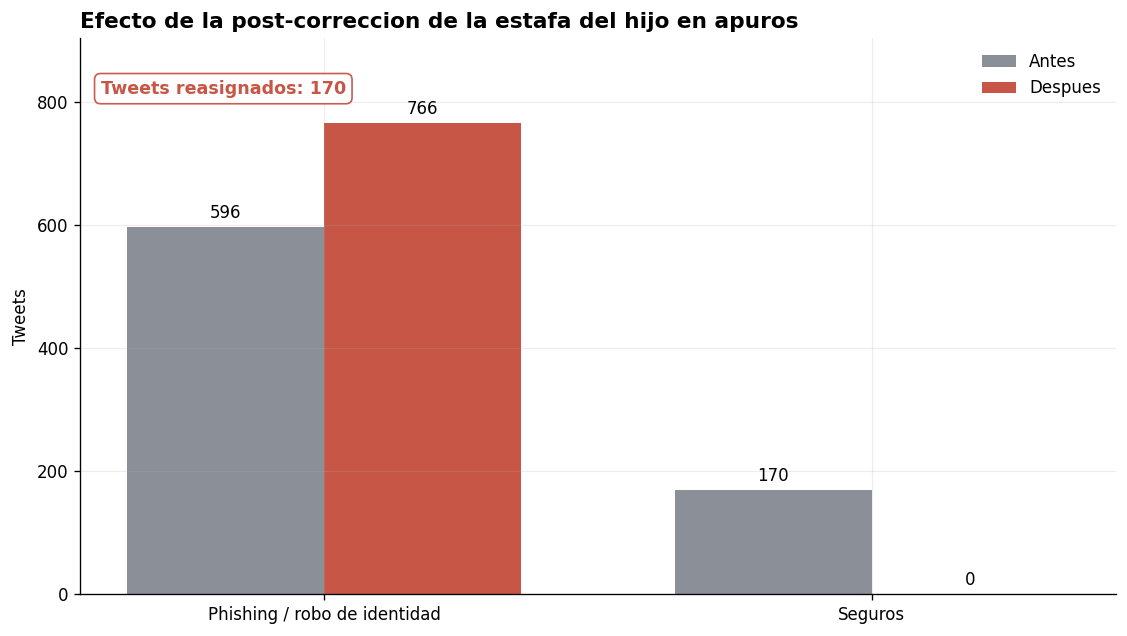

,Categoria,Antes,Despues
0,Phishing / robo de identidad,596,766
1,Seguros,170,0


In [23]:
if "predicted_category_original" not in es.columns:
    print("El CSV espanol no contiene predicted_category_original; se omite esta figura.")
else:
    before = es["predicted_category_original"].fillna(es["predicted_category"])
    after = es["predicted_category"]
    changed = before.ne(after)
    corrected_n = int(changed.sum())
    focus_categories = ["phishing_identity", "insurance"]
    corr_df = pd.DataFrame({
        "Categoria": [label_category(cat) for cat in focus_categories],
        "Antes": [int((before == cat).sum()) for cat in focus_categories],
        "Despues": [int((after == cat).sum()) for cat in focus_categories],
    })
    export_table(
        corr_df,
        "tabla_postcorreccion_hijo_apuros",
        caption="Efecto de la post-correccion de la estafa del hijo en apuros.",
        label="tab:postcorreccion_hijo_apuros",
    )

    x = np.arange(len(corr_df))
    width = 0.36
    fig, ax = plt.subplots(figsize=(9.5, 5.4))
    bars_before = ax.bar(x - width / 2, corr_df["Antes"], width, label="Antes", color="#8A8F98")
    bars_after = ax.bar(x + width / 2, corr_df["Despues"], width, label="Despues", color=COUNTRY_COLORS["Espana"])
    ax.set_xticks(x)
    ax.set_xticklabels(corr_df["Categoria"])
    ax.set_ylabel("Tweets")
    ax.set_title("Efecto de la post-correccion de la estafa del hijo en apuros", loc="left", fontweight="bold")
    ax.set_ylim(0, max(corr_df[["Antes", "Despues"]].to_numpy().max() * 1.18, 50))
    ax.legend()
    ax.bar_label(bars_before, padding=3)
    ax.bar_label(bars_after, padding=3)
    ax.text(
        0.02, 0.90, f"Tweets reasignados: {corrected_n}",
        transform=ax.transAxes, fontsize=10.5, fontweight="bold", color=COUNTRY_COLORS["Espana"],
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": COUNTRY_COLORS["Espana"], "linewidth": 1.0, "alpha": 0.96},
        zorder=10, clip_on=False,
    )
    fig.tight_layout()
    save_figure(fig, "fig_06_postcorreccion_hijo_apuros")
    plt.show()
    display(corr_df)


## 9. Figura: topicos BERTopic del corpus estadounidense

**Donde ponerla:** `Resultados`, subseccion de exploracion tematica.

**Titulo sugerido:** `Principales topicos emergentes en el corpus estadounidense`.

**Leyenda sugerida:** `Topicos generados mediante BERTopic sobre el corpus estadounidense. Se excluye el topico -1, correspondiente a outliers. Las etiquetas muestran palabras clave representativas tras retirar conectores frecuentes.`

Guardado: docs/overleaf/tables/tabla_topicos_bertopic_eeuu.csv
Guardado: docs/overleaf/tables/tabla_topicos_bertopic_eeuu.tex
Guardado: docs/overleaf/figures/fig_07_topicos_bertopic_eeuu.png
Guardado: docs/overleaf/figures/fig_07_topicos_bertopic_eeuu.pdf


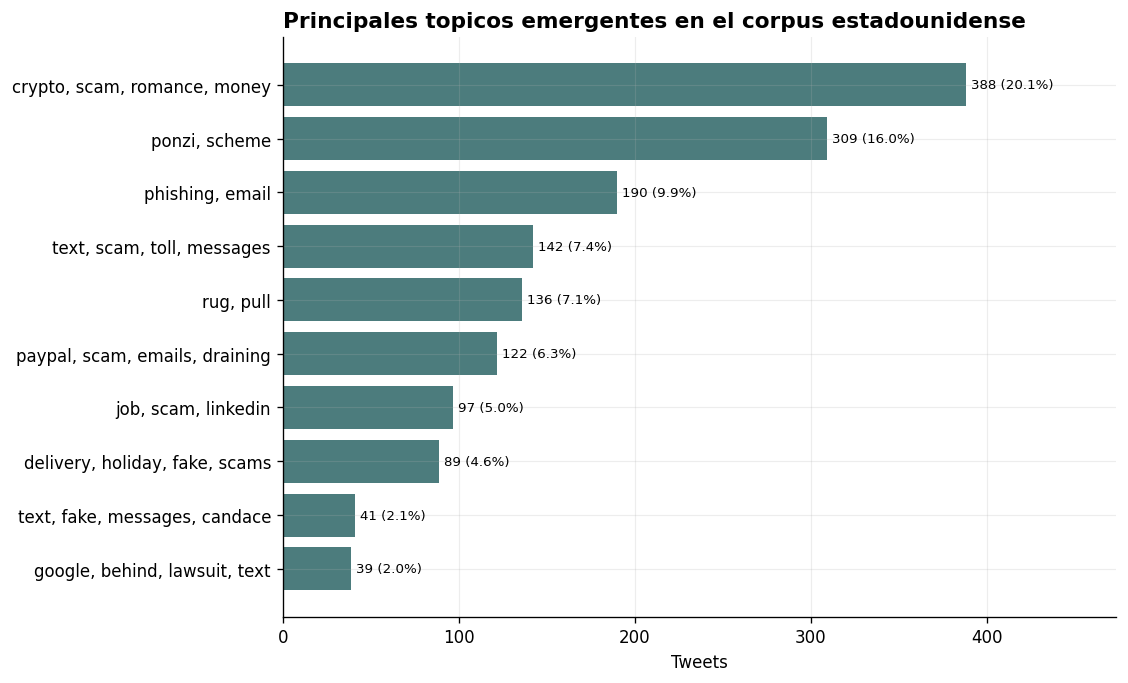

,Topic ID,Etiqueta visual,Tweets,% corpus,Keywords originales
1,0,"crypto, scam, romance, money",388,20.1,"crypto, scam, to, romance, money, and, in, for"
2,1,"ponzi, scheme",309,16.0,"ponzi, scheme, the, is, to, and, of, it"
3,2,"phishing, email",190,9.9,"phishing, email, and, it, to, your, the, you"
4,3,"text, scam, toll, messages",142,7.4,"text, scam, toll, the, to, messages, and, from"
5,4,"rug, pull",136,7.1,"rug, pull, the, this, is, be, to, will"
6,5,"paypal, scam, emails, draining",122,6.3,"paypal, scam, to, emails, the, draining, sneak..."
7,6,"job, scam, linkedin",97,5.0,"job, scam, to, for, the, linkedin, are, of"
8,7,"delivery, holiday, fake, scams",89,4.6,"delivery, holiday, fake, and, scams, package, ..."
9,8,"text, fake, messages, candace",41,2.1,"text, fake, messages, and, candace, her, the, she"
10,9,"google, behind, lawsuit, text",39,2.0,"google, behind, lawsuit, text, china, lighthou..."


In [24]:
def clean_topic_label(keyword_string, max_words=4):
    words = []
    for raw in str(keyword_string).split(","):
        word = raw.strip().lower()
        if word and word not in TOPIC_STOPWORDS and word not in words:
            words.append(word)
    return ", ".join(words[:max_words]) if words else str(keyword_string)

def topic_summary(df, top_n=10):
    if "bertopic_id" not in df.columns or "bertopic_keywords" not in df.columns:
        return pd.DataFrame()
    topics = (
        df.groupby(["bertopic_id", "bertopic_keywords"])
        .size()
        .reset_index(name="n_tweets")
    )
    topics["bertopic_id_num"] = pd.to_numeric(topics["bertopic_id"], errors="coerce")
    topics = topics[topics["bertopic_id_num"] != -1]
    topics["pct"] = topics["n_tweets"] / len(df) * 100
    topics["topic_label"] = topics["bertopic_keywords"].map(clean_topic_label)
    return topics.sort_values("n_tweets", ascending=False).head(top_n)

topics_us = topic_summary(us, top_n=10)
topics_us_table = topics_us[["bertopic_id", "topic_label", "n_tweets", "pct", "bertopic_keywords"]].copy()
topics_us_table.columns = ["Topic ID", "Etiqueta visual", "Tweets", "% corpus", "Keywords originales"]
topics_us_table["% corpus"] = topics_us_table["% corpus"].round(1)

export_table(
    topics_us_table,
    "tabla_topicos_bertopic_eeuu",
    caption="Topicos BERTopic principales del corpus estadounidense.",
    label="tab:topicos_bertopic_eeuu",
)

plot_topics = topics_us.sort_values("n_tweets", ascending=True)
fig, ax = plt.subplots(figsize=(9.5, 5.8))
bars = ax.barh(plot_topics["topic_label"], plot_topics["n_tweets"], color="#4C7C7D")
ax.set_xlabel("Tweets")
ax.set_title("Principales topicos emergentes en el corpus estadounidense", loc="left", fontweight="bold")
ax.bar_label(bars, labels=[f"{n} ({p:.1f}%)" for n, p in zip(plot_topics["n_tweets"], plot_topics["pct"])], padding=3, fontsize=8)
ax.set_xlim(0, plot_topics["n_tweets"].max() * 1.22)
fig.tight_layout()
save_figure(fig, "fig_07_topicos_bertopic_eeuu")
plt.show()

display(topics_us_table)


## 10. Diagnostico BERTopic del corpus espanol

**Donde ponerlo:** normalmente no como figura principal. El BERTopic espanol del CSV final puede estar dominado por stopwords si no se ha ejecutado el notebook `11_bertopic_espana_stopwords.ipynb`.

**Uso recomendado:** ejecutar esta celda como control de calidad. Si el topico principal concentra una proporcion excesiva y sus keywords son conectores (`de`, `en`, `la`, `el`...), no incluir la figura espanola en el cuerpo principal del TFM hasta regenerar topicos con stopwords filtradas.

In [25]:
topics_es = topic_summary(es, top_n=10)
if topics_es.empty:
    print("No hay columnas BERTopic en el corpus espanol.")
else:
    largest_share = topics_es["pct"].max()
    print("Topicos espanoles detectados en el CSV actual:")
    display(topics_es[["bertopic_id", "topic_label", "n_tweets", "pct", "bertopic_keywords"]])
    if largest_share > 70:
        print("\nAVISO: el topico principal supera el 70% del corpus. Recomendacion: ejecutar notebooks/11_bertopic_espana_stopwords.ipynb antes de incluir una figura BERTopic de Espana.")
    else:
        plot_topics = topics_es.sort_values("n_tweets", ascending=True)
        fig, ax = plt.subplots(figsize=(9.5, 5.8))
        bars = ax.barh(plot_topics["topic_label"], plot_topics["n_tweets"], color=COUNTRY_COLORS["Espana"])
        ax.set_xlabel("Tweets")
        ax.set_title("Principales topicos emergentes en el corpus espanol", loc="left", fontweight="bold")
        ax.bar_label(bars, labels=[f"{n} ({p:.1f}%)" for n, p in zip(plot_topics["n_tweets"], plot_topics["pct"])], padding=3, fontsize=8)
        ax.set_xlim(0, plot_topics["n_tweets"].max() * 1.22)
        fig.tight_layout()
        save_figure(fig, "fig_08_topicos_bertopic_espana")
        plt.show()


Topicos espanoles detectados en el CSV actual:


,bertopic_id,topic_label,n_tweets,pct,bertopic_keywords
1,0,estafa,1137,92.514239,"de, en, la, el, que, por, una, estafa"
2,1,"fraude, hijo, apuros",31,2.522376,"de, en, fraude, la, hijo, apuros, una, del"



AVISO: el topico principal supera el 70% del corpus. Recomendacion: ejecutar notebooks/11_bertopic_espana_stopwords.ipynb antes de incluir una figura BERTopic de Espana.


## 11. Figura de anexo: diagnostico del modelo mDeBERTa descartado

**Donde ponerla:** `Anexo`, no en el cuerpo principal salvo que querais explicar con detalle la trazabilidad metodologica.

**Titulo sugerido:** `Anomalia de clasificacion en el modelo mDeBERTa para el corpus espanol`.

**Leyenda sugerida:** `Distribucion anomala observada en la clasificacion preliminar con mDeBERTa y etiquetas largas en espanol. La categoria charity absorbio una proporcion desproporcionada del corpus, con baja confianza media, lo que motivo el descarte del modelo.`

Nota: esta figura usa los valores documentados en los notebooks de diagnostico porque el CSV mDeBERTa descartado no esta versionado en el repositorio.

Guardado: docs/overleaf/tables/tabla_diagnostico_mdeberta_descartado.csv
Guardado: docs/overleaf/tables/tabla_diagnostico_mdeberta_descartado.tex
Guardado: docs/overleaf/figures/fig_anexo_diagnostico_mdeberta_descartado.png
Guardado: docs/overleaf/figures/fig_anexo_diagnostico_mdeberta_descartado.pdf


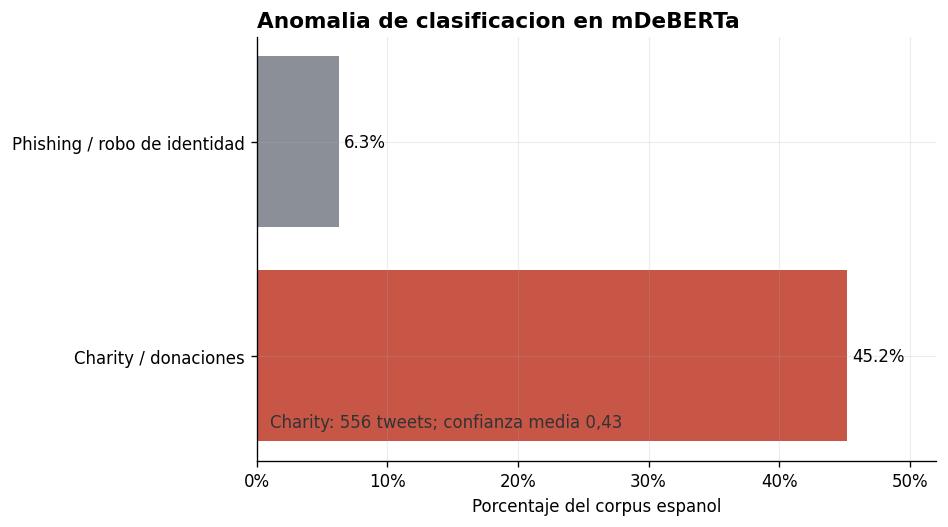

,Categoria,Porcentaje,Tweets,Confianza media
0,Charity / donaciones,45.2,556,0.43
1,Phishing / robo de identidad,6.3,77,NaN


In [26]:
mdeberta_diag = pd.DataFrame([
    {"Categoria": "Charity / donaciones", "Porcentaje": 45.2, "Tweets": 556, "Confianza media": 0.43},
    {"Categoria": "Phishing / robo de identidad", "Porcentaje": 6.3, "Tweets": round(1229 * 0.063), "Confianza media": np.nan},
])

export_table(
    mdeberta_diag,
    "tabla_diagnostico_mdeberta_descartado",
    caption="Diagnostico del modelo mDeBERTa descartado para el corpus espanol.",
    label="tab:diagnostico_mdeberta",
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(mdeberta_diag["Categoria"], mdeberta_diag["Porcentaje"], color=["#C75646", "#8A8F98"])
ax.set_xlabel("Porcentaje del corpus espanol")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.set_title("Anomalia de clasificacion en mDeBERTa", loc="left", fontweight="bold")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in mdeberta_diag["Porcentaje"]], padding=3)
ax.text(0.02, 0.08, "Charity: 556 tweets; confianza media 0,43", transform=ax.transAxes, fontsize=10, color="#333333")
ax.set_xlim(0, 52)
fig.tight_layout()
save_figure(fig, "fig_anexo_diagnostico_mdeberta_descartado")
plt.show()

display(mdeberta_diag)


## 12. Tablas opcionales para anexo: ubicaciones agregadas e interacciones

**Donde ponerlas:** `Anexo` o `Materiales y Metodos` si necesitais justificar el filtrado geografico.

**Importante:** son agregados. No exportan usernames ni texto de tweets.

In [27]:
def top_locations_table(df, country, n=12):
    loc = (
        df["user_location"]
        .fillna("")
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(n)
        .reset_index()
    )
    loc.columns = ["Ubicacion declarada", "Tweets"]
    loc.insert(0, "Corpus", country)
    return loc

tabla_ubicaciones = pd.concat([
    top_locations_table(us, "Estados Unidos"),
    top_locations_table(es, "Espana"),
], ignore_index=True)

engagement = (
    combined.groupby(["country", "predicted_category"])
    .agg(
        tweets=("tweet_id", "count"),
        likes_mediana=("like_count", "median"),
        likes_media=("like_count", "mean"),
        retweets_mediana=("retweet_count", "median"),
        retweets_media=("retweet_count", "mean"),
    )
    .reset_index()
)
engagement["Categoria"] = engagement["predicted_category"].map(label_category)
engagement = engagement[["country", "Categoria", "tweets", "likes_mediana", "likes_media", "retweets_mediana", "retweets_media"]]
for col in ["likes_mediana", "likes_media", "retweets_mediana", "retweets_media"]:
    engagement[col] = engagement[col].round(2)

export_table(
    tabla_ubicaciones,
    "tabla_top_ubicaciones_agregadas",
    caption="Ubicaciones declaradas mas frecuentes tras el filtrado geografico.",
    label="tab:top_ubicaciones",
)
export_table(
    engagement,
    "tabla_interacciones_por_categoria",
    caption="Metricas de interaccion por categoria predicha.",
    label="tab:interacciones_categoria",
)

display(tabla_ubicaciones)
display(engagement.head(20))


Guardado: docs/overleaf/tables/tabla_top_ubicaciones_agregadas.csv
Guardado: docs/overleaf/tables/tabla_top_ubicaciones_agregadas.tex
Guardado: docs/overleaf/tables/tabla_interacciones_por_categoria.csv
Guardado: docs/overleaf/tables/tabla_interacciones_por_categoria.tex


,Corpus,Ubicacion declarada,Tweets
0,Estados Unidos,United States,141
1,Estados Unidos,USA,73
2,Estados Unidos,"New York, NY",36
3,Estados Unidos,"Los Angeles, CA",28
4,Estados Unidos,"Texas, USA",25
5,Estados Unidos,"Washington, DC",22
6,Estados Unidos,"Chicago, IL",21
7,Estados Unidos,"Florida, USA",20
8,Estados Unidos,"California, USA",20
9,Estados Unidos,"Atlanta, GA",18


,country,Categoria,tweets,likes_mediana,likes_media,retweets_mediana,retweets_media
0,Espana,Banco / transferencias,115,0.0,8.67,0.0,4.50
1,Espana,Caridad / donaciones,19,1.0,14.68,0.0,11.11
2,Espana,Corporativo / bursatil,8,1.5,4.88,1.5,3.00
3,Espana,Empleo,44,0.0,2.02,0.0,0.98
4,Espana,Suplantacion publica,38,0.0,3.37,0.0,2.42
5,Espana,Inversion / cripto,163,0.0,3.42,0.0,1.75
6,Espana,No relacionado,3,0.0,0.00,0.0,0.00
7,Espana,Apps de pago,2,0.0,0.00,0.0,0.00
8,Espana,Phishing / robo de identidad,766,0.0,3.91,0.0,1.92
9,Espana,Ponzi / piramidal,7,1.0,347.71,1.0,228.57


## 13. Resumen de archivos generados

**Uso en el TFM:** esta celda solo sirve para verificar que todo se ha exportado correctamente.

En Overleaf, las figuras se pueden incluir desde `figures/nombre_figura.pdf` o `figures/nombre_figura.png`, dependiendo de lo que prefirais.

In [28]:
generated_figures = sorted([p.relative_to(REPO_ROOT) for p in FIG_DIR.glob("fig_*.png")])
generated_tables = sorted([p.relative_to(REPO_ROOT) for p in TABLE_DIR.glob("*.csv")])

print("Figuras PNG generadas:")
for path in generated_figures:
    print(f"- {path}")

print("\nTablas CSV generadas:")
for path in generated_tables:
    print(f"- {path}")


Figuras PNG generadas:
- docs/overleaf/figures/fig_01_flujo_construccion_corpus.png
- docs/overleaf/figures/fig_02_distribucion_categorias_comparada.png
- docs/overleaf/figures/fig_03_evolucion_mensual_categorias.png
- docs/overleaf/figures/fig_04_confianza_clasificador_por_categoria.png
- docs/overleaf/figures/fig_05_heatmap_query_categoria.png
- docs/overleaf/figures/fig_06_postcorreccion_hijo_apuros.png
- docs/overleaf/figures/fig_07_topicos_bertopic_eeuu.png
- docs/overleaf/figures/fig_anexo_diagnostico_mdeberta_descartado.png

Tablas CSV generadas:
- docs/overleaf/tables/tabla_caracteristicas_corpus.csv
- docs/overleaf/tables/tabla_confianza_clasificador.csv
- docs/overleaf/tables/tabla_diagnostico_mdeberta_descartado.csv
- docs/overleaf/tables/tabla_distribucion_categorias.csv
- docs/overleaf/tables/tabla_interacciones_por_categoria.csv
- docs/overleaf/tables/tabla_postcorreccion_hijo_apuros.csv
- docs/overleaf/tables/tabla_top_ubicaciones_agregadas.csv
- docs/overleaf/tables/tab